In [85]:
# Customer Personality Analysis - Unsupervised Learning Tugas 3


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset

In [86]:
#

df = pd.read_csv('cpa.csv',sep=r"\t",engine="python")
print(df.columns)
df.set_index("ID",inplace=True)
df.sort_index(inplace=True)
df.head()

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
0,1985,Graduation,Married,70951.0,0,0,04-05-2013,66,239,10,...,1,0,0,0,0,0,0,3,11,0
1,1961,Graduation,Single,57091.0,0,0,15-06-2014,0,464,5,...,5,0,0,0,0,1,0,3,11,1
9,1975,Master,Single,46098.0,1,1,18-08-2012,86,57,0,...,8,0,0,0,0,0,0,3,11,0
13,1947,PhD,Widow,25358.0,0,1,22-07-2013,57,19,0,...,6,0,0,0,0,0,0,3,11,0
17,1971,PhD,Married,60491.0,0,1,06-09-2013,81,637,47,...,5,0,0,0,0,0,0,3,11,0


#Step2: lakukan Eksplorasi awal

In [87]:
df.columns = df.columns.str.strip().str.lower()
    
df1 = df.copy()
stausMap = {
    "Married" : "married",
    "Single" : "single",
    "Widow" : "single",
    "Divorced" : "single",
    "Alone" : "single",
    "Absurd" : "single",
    "YOLO" : "single",
    "Together" : "married"
}
edMap = {
    "graduation" : "undergrad",
    "2n cycle" : "undergrad"
}
df1["marital_status"] = df1["marital_status"].replace(stausMap)
df1["education"] = df1["education"].replace(edMap).str.lower()
for c in df1.columns:
    print(f"{c} {df1[c].unique()}\n")

df1

year_birth [1985 1961 1975 1947 1971 1965 1976 1960 1958 1987 1964 1970 1963 1972
 1953 1982 1969 1981 1988 1951 1966 1945 1977 1986 1980 1956 1946 1996
 1962 1948 1955 1979 1967 1952 1959 1973 1989 1968 1978 1957 1950 1974
 1954 1944 1991 1984 1949 1983 1992 1899 1943 1990 1993 1995 1994 1940
 1941 1900 1893]

education ['graduation' 'master' 'phd' '2n cycle' 'basic']

marital_status ['married' 'single']

income [ 70951.  57091.  46098. ... 156924.  26487.  41411.]

kidhome [0 1 2]

teenhome [0 1 2]

dt_customer ['04-05-2013' '15-06-2014' '18-08-2012' '22-07-2013' '06-09-2013'
 '01-09-2013' '03-12-2012' '15-02-2014' '16-11-2012' '08-09-2012'
 '24-04-2014' '11-05-2014' '07-12-2012' '18-09-2013' '26-05-2013'
 '25-07-2013' '15-09-2013' '26-08-2013' '09-12-2013' '12-05-2014'
 '16-07-2013' '26-03-2013' '06-01-2013' '15-05-2013' '25-08-2013'
 '15-11-2013' '17-10-2013' '17-11-2013' '13-10-2012' '10-01-2013'
 '02-01-2014' '18-02-2013' '11-05-2013' '17-02-2014' '09-06-2014'
 '26-08-2012' '20-0

,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response
ID,,,,,,,,,,,,,,,,,,,,,
0,1985,graduation,married,70951.0,0,0,04-05-2013,66,239,10,...,1,0,0,0,0,0,0,3,11,0
1,1961,graduation,single,57091.0,0,0,15-06-2014,0,464,5,...,5,0,0,0,0,1,0,3,11,1
9,1975,master,single,46098.0,1,1,18-08-2012,86,57,0,...,8,0,0,0,0,0,0,3,11,0
13,1947,phd,single,25358.0,0,1,22-07-2013,57,19,0,...,6,0,0,0,0,0,0,3,11,0
17,1971,phd,married,60491.0,0,1,06-09-2013,81,637,47,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11178,1972,master,single,42394.0,1,0,23-03-2014,69,15,2,...,7,0,0,0,0,0,0,3,11,0
11181,1949,phd,married,156924.0,0,0,29-08-2013,85,2,1,...,0,0,0,0,0,0,0,3,11,0
11187,1978,basic,single,26487.0,1,0,20-05-2013,23,2,8,...,5,0,0,0,0,0,0,3,11,0


# Step 3: Identifikasi kolom numerik & kategori

In [88]:
colKategori = []
colNumeric = []

for col in df1.select_dtypes(include=["object"]).columns:
    colKategori.append(col)

for col in df1.select_dtypes(include=["number"]).columns:
    if col in ["z_costcontact" , "z_revenue"]:
        colNumeric.append(col)
        continue
    unique_vals = sorted(df1[col].dropna().drop_duplicates().unique())

    if len(unique_vals) > 2:
        #diff >= 1
        diff = all(
            (unique_vals[i + 1] - unique_vals[i]) >= 1
            for i in range(len(unique_vals) - 1)
        )
        if diff:
            colNumeric.append(col)
    else :
        colKategori.append(col)
print(colNumeric)
print(colKategori)
df1.info()



['year_birth', 'income', 'kidhome', 'teenhome', 'recency', 'mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts', 'mntgoldprods', 'numdealspurchases', 'numwebpurchases', 'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth', 'z_costcontact', 'z_revenue']
['education', 'marital_status', 'dt_customer', 'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1', 'acceptedcmp2', 'complain', 'response']
<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 0 to 11191
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year_birth           2240 non-null   int64  
 1   education            2240 non-null   object 
 2   marital_status       2240 non-null   object 
 3   income               2216 non-null   float64
 4   kidhome              2240 non-null   int64  
 5   teenhome             2240 non-null   int64  
 6   dt_customer          2240 non-null   object 
 7 

# Step 4: Imputasi missing value

year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
acceptedcmp3            0
acceptedcmp4            0
acceptedcmp5            0
acceptedcmp1            0
acceptedcmp2            0
complain                0
z_costcontact           0
z_revenue               0
response                0
dtype: int64


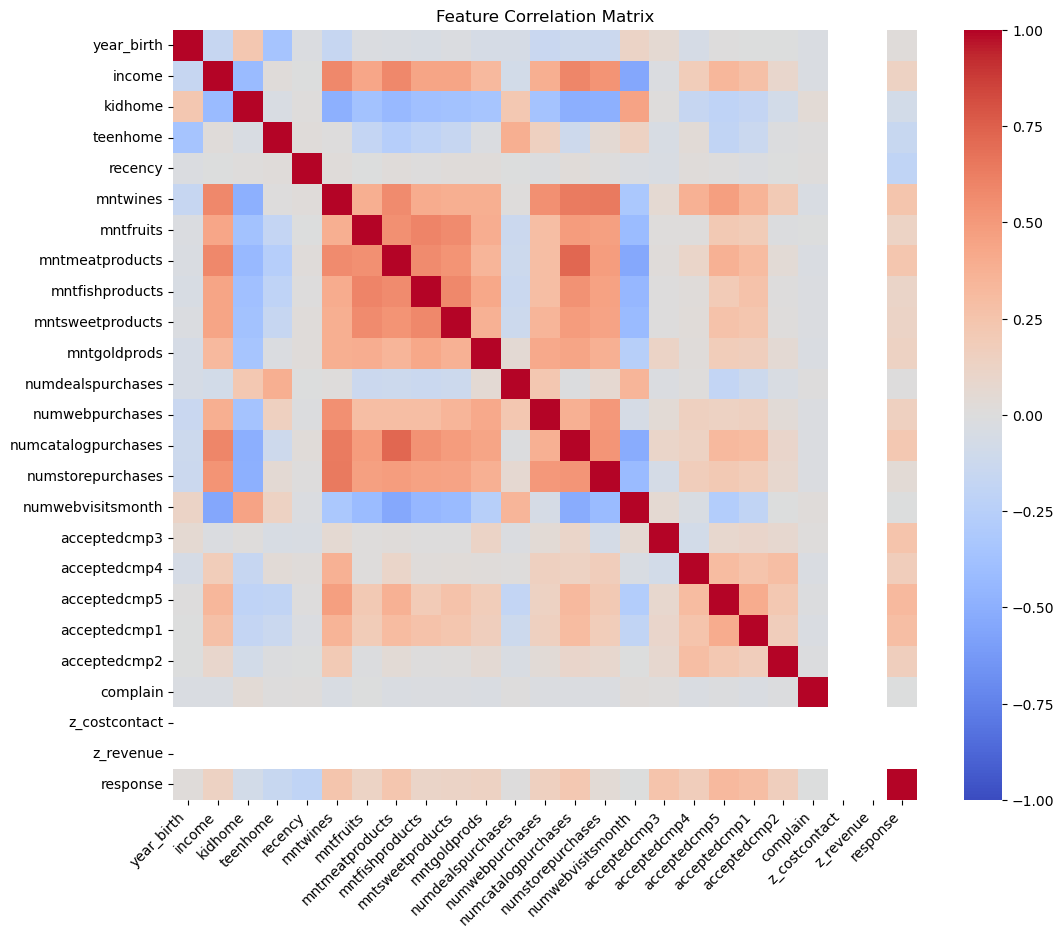

['numcatalogpurchases', 'mntmeatproducts', 'mntwines', 'numstorepurchases', 'mntsweetproducts', 'mntfishproducts', 'mntfruits', 'numwebpurchases', 'acceptedcmp5', 'mntgoldprods', 'acceptedcmp1']
year_birth             0
education              0
marital_status         0
income                 0
kidhome                0
teenhome               0
dt_customer            0
recency                0
mntwines               0
mntfruits              0
mntmeatproducts        0
mntfishproducts        0
mntsweetproducts       0
mntgoldprods           0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
acceptedcmp3           0
acceptedcmp4           0
acceptedcmp5           0
acceptedcmp1           0
acceptedcmp2           0
complain               0
z_costcontact          0
z_revenue              0
response               0
dtype: int64


In [ ]:
dffilna = df1.copy()
print(dffilna.isna().sum())
corrMatrix = dffilna.select_dtypes(include=["number"]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corrMatrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45,ha="right")
plt.show()
targetScore = 0.2
income_corr = corrMatrix["income"]
filtered_income_corr = income_corr[(income_corr > targetScore) & (income_corr < 1.0)]
income_corr = list(filtered_income_corr.sort_values(ascending=False).index)

print(income_corr)
group_means = dffilna.groupby(income_corr)[
    "income"
].transform("mean")
dffilna["income"] = dffilna["income"].fillna(group_means)
dffilna["income"] = dffilna["income"].fillna(dffilna["income"].mean())

print(dffilna.isna().sum())


# Step 5: Encoding fitur kategori

#Gabungkan data numerik & hasil encoding

# Step 6: Scaling data


# Step 7: Tentukan jumlah cluster optimal (Elbow + Silhouette)

# Step 8: Pilih k optimal dan klasterisasi

# Step 9: Visualisasi klaster dengan PCA 2D

# Step 10: Profiling cluster (rata-rata fitur per cluster)

# Simpulkan Analisa dari hasil